# Module 4: Deep Learning — Brain Tumor Segmentation
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Pixel-wise binary segmentation — which pixels belong to the tumor?

**Group members**: Martin Caro, Edison Zyberaj


# Brain Tumor Segmentation
**Requires 01_train_test.** Loads paths from Drive, trains U-Net, saves model.

## 1. Install dependencies

In [1]:
!pip install git+https://github.com/tensorflow/examples.git
!pip install -U keras
!pip install -q tensorflow_datasets
!pip install -q -U tensorflow-text tensorflow

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-x8m12646
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-x8m12646
  Resolved https://github.com/tensorflow/examples.git to commit 7d64849545cd682230dce48b8cc8bc375d95d1e8
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1779265295.715865470489431931060322430528026120936890946024-py3-none-any.whl size=300309 sha256=c806ae94131aac4c76a8658e42e8b84945da15e61a737094a6b6d3eaedb9b3a6
  Stored in directory: /tmp/pip-ephem-wheel-cache-72vezyze/wheels/ab/17/30/d16d07e2c95286770a9ddcd6f41629ea92b998858c5ee235aa
Successfully built tensorflow-examples
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


## 2. Mount Drive and check setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/CV_Project'
os.makedirs(DRIVE + '/brain/images', exist_ok=True)
os.makedirs(DRIVE + '/brain/masks',  exist_ok=True)
os.makedirs(DRIVE + '/splits',       exist_ok=True)
os.makedirs(DRIVE + '/models',       exist_ok=True)
os.makedirs(DRIVE + '/results',      exist_ok=True)
print('Drive mounted ✓  —  ' + DRIVE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✓  —  /content/drive/MyDrive/CV_Project


In [3]:
import os, json
assert os.path.exists(DRIVE + '/splits/seg_paths.json'),     '❌ Run 01_train_test.ipynb first.'

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output
import matplotlib.pyplot as plt

with open(DRIVE + '/splits/seg_paths.json') as f:
    paths = json.load(f)

train_img = paths['train_img']
train_msk = paths['train_msk']
val_img   = paths['val_img']
val_msk   = paths['val_msk']

print(f'Train: {len(train_img)} | Val: {len(val_img)}')

Train: 3143 | Val: 786


## 3. Data pipeline

In [4]:
def normalize(input_image, input_mask):
  return input_image, input_mask

def load_image(image_path, mask_path):
  image    = tf.io.read_file(image_path)
  image    = tf.image.decode_png(image, channels=3)
  image    = tf.image.resize(image, (128, 128))
  raw_mask = tf.io.read_file(mask_path)
  mask     = tf.image.decode_png(raw_mask, channels=1)
  mask     = tf.image.resize(mask, (128, 128),
                 method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  return normalize(tf.cast(image, tf.float32) / 255.0,
                   tf.cast(mask > 127, tf.int32))

In [5]:
TRAIN_LENGTH    = len(train_img)
BATCH_SIZE      = 32
BUFFER_SIZE     = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train_images = tf.data.Dataset.from_tensor_slices((train_img, train_msk)).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images  = tf.data.Dataset.from_tensor_slices((val_img, val_msk)).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE)

class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    self.augment_inputs = tf.keras.layers.RandomFlip(mode='horizontal', seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode='horizontal', seed=seed)
  def call(self, inputs, labels):
    return self.augment_inputs(inputs), self.augment_labels(labels)

train_batches = (train_images.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
    .repeat().map(Augment()).prefetch(buffer_size=tf.data.AUTOTUNE))
test_batches  = test_images.batch(BATCH_SIZE)

print(f'Steps per epoch: {STEPS_PER_EPOCH}')

Steps per epoch: 98


## 4. Visualize sample

[data] loading from saved splits...
[data] loaded in 14.5s  —  shape: (3143, 128, 128, 3)
[display] showing tumor sample...


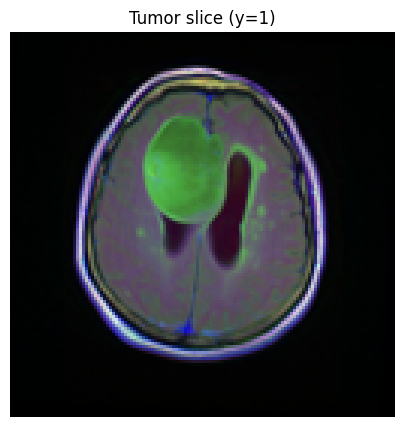

[display] rendered in 0.19s
[display] done


In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time

print('[data] loading from saved splits...')
t0 = time.time()

x_train = np.load(DRIVE + '/splits/x_train.npy')
y_train = np.load(DRIVE + '/splits/y_train.npy')

print(f'[data] loaded in {time.time()-t0:.1f}s  —  shape: {x_train.shape}')

tumor_idx = int(np.argwhere(y_train == 1)[0][0])

sample_image = tf.constant(x_train[tumor_idx])
sample_mask  = tf.constant(y_train[tumor_idx:tumor_idx+1])

def display(display_list, titles=None):
    t0 = time.time()
    titles = titles or ['Input Image', 'True Mask', 'Predicted Mask']
    plt.figure(figsize=(15, 5))
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(titles[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()
    print(f'[display] rendered in {time.time()-t0:.2f}s')

print('[display] showing tumor sample...')
display(
    [sample_image],
    titles=[f'Tumor slice (y={y_train[tumor_idx]})']
)
print('[display] done')

## 5. Build U-Net

In [7]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)
layer_names = ['block_1_expand_relu','block_3_expand_relu',
               'block_6_expand_relu','block_13_expand_relu','block_16_project']
base_model_outputs = [base_model.get_layer(n).output for n in layer_names]
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False

up_stack = [pix2pix.upsample(512,3), pix2pix.upsample(256,3),
            pix2pix.upsample(128,3), pix2pix.upsample(64,3)]

def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[128, 128, 3])
  skips  = down_stack(inputs)
  x      = skips[-1]
  skips  = reversed(skips[:-1])
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])
  x = tf.keras.layers.Conv2DTranspose(
      filters=output_channels, kernel_size=3, strides=2, padding='same')(x)
  return tf.keras.Model(inputs=inputs, outputs=x)

OUTPUT_CLASSES = 2
model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 6. Train

In [10]:
import numpy as np
import tensorflow as tf
from PIL import Image
import glob

image_pngs = sorted(glob.glob(DRIVE + '/brain/images/*.png'))
mask_pngs  = sorted(glob.glob(DRIVE + '/brain/masks/*.png'))

# Find first slice that actually has a tumor in its mask
tumor_idx = next(
    i for i, m in enumerate(mask_pngs)
    if np.array(Image.open(m)).max() > 0
)

# Image: (128, 128, 3) float32 in [0, 1]
img_arr      = np.array(Image.open(image_pngs[tumor_idx]), dtype=np.float32) / 255.0
sample_image = tf.constant(img_arr)

# Mask: (128, 128, 1) int32 — binary pixel mask, NOT a classification label
msk_arr     = np.array(Image.open(mask_pngs[tumor_idx]).convert('L'), dtype=np.int32)
msk_arr     = (msk_arr > 127).astype(np.int32)[..., np.newaxis]
sample_mask = tf.constant(msk_arr)

print(f'sample_image shape: {sample_image.shape}')  # must be (128, 128, 3)
print(f'sample_mask  shape: {sample_mask.shape}')   # must be (128, 128, 1)

sample_image shape: (128, 128, 3)
sample_mask  shape: (128, 128, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


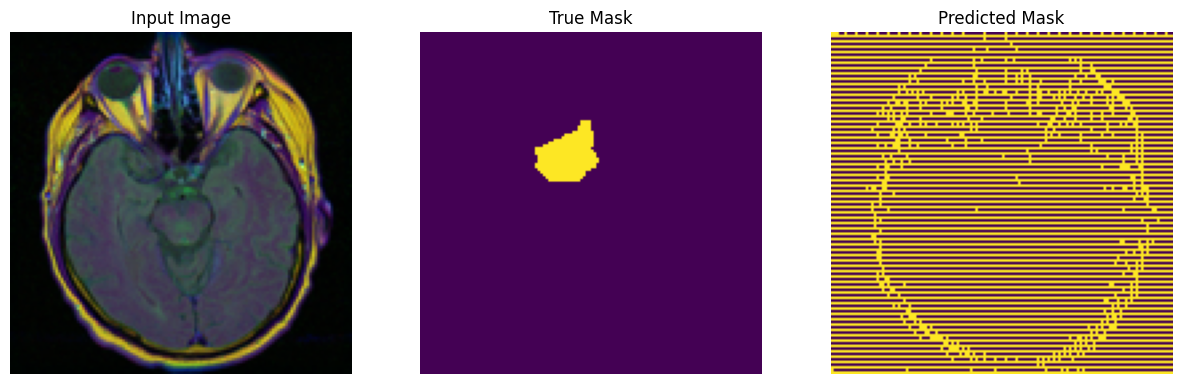

[display] rendered in 0.24s


In [11]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      display([image[0], mask[0], create_mask(model.predict(image))])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

show_predictions()

class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True); show_predictions()
    print('\nSample Prediction after epoch {}\n'.format(epoch+1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


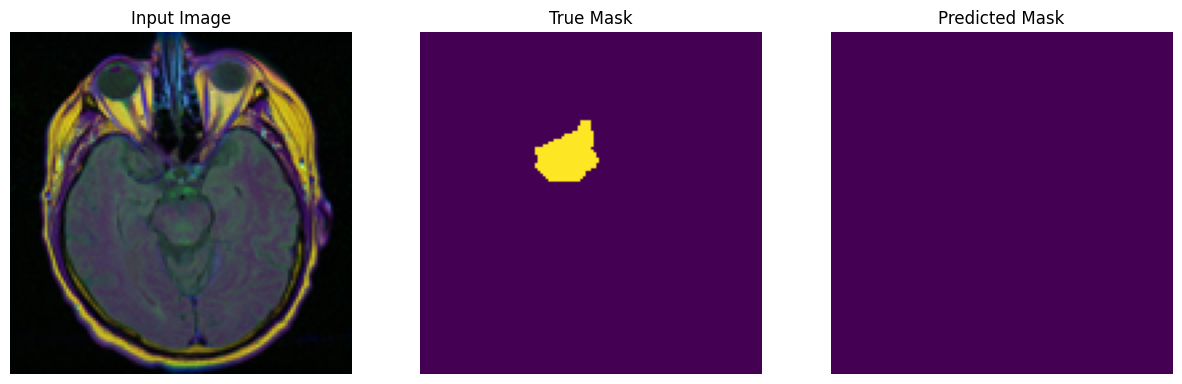

[display] rendered in 0.36s

Sample Prediction after epoch 10

98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9939 - loss: 0.0177 - val_accuracy: 0.9914 - val_loss: 0.0265


In [13]:
class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            clear_output(wait=True)
            show_predictions()
            print('\nSample Prediction after epoch {}\n'.format(epoch+1))
        else:
            print(f'Epoch {epoch+1}/10 done — loss: {logs["loss"]:.4f}  '
                  f'val_loss: {logs["val_loss"]:.4f}')

EPOCHS           = 10
VAL_SUBSPLITS    = 5
VALIDATION_STEPS = max(1, len(val_img) // BATCH_SIZE // VAL_SUBSPLITS)

model_history = model.fit(train_batches, epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH, validation_steps=VALIDATION_STEPS,
    validation_data=test_batches, callbacks=[DisplayCallback()])

## 7. Loss curve

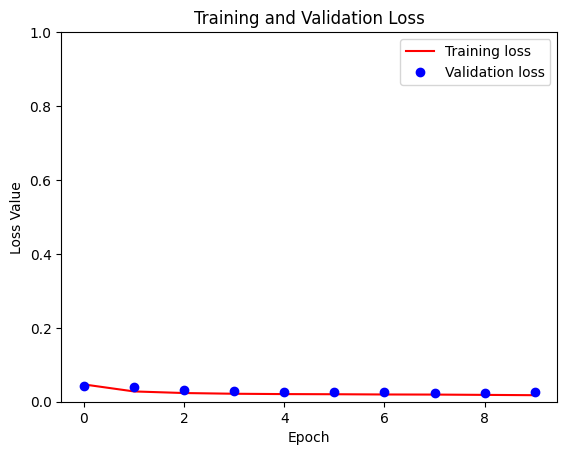

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


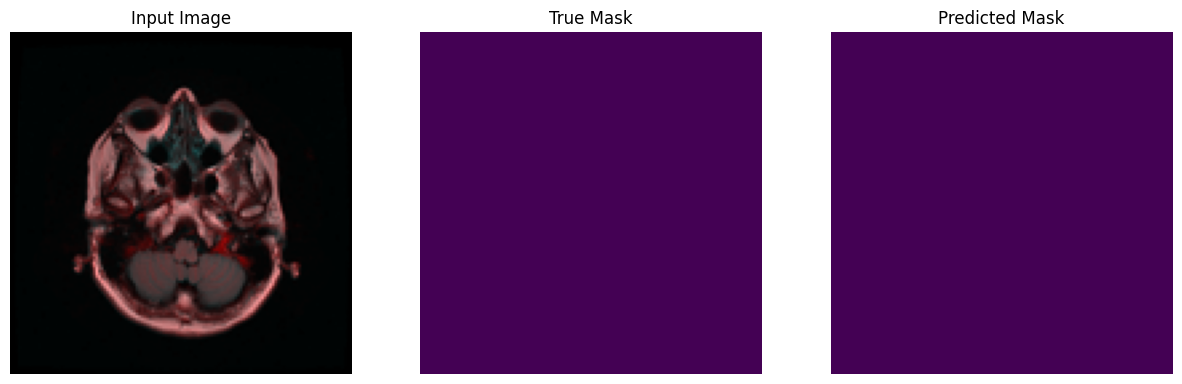

[display] rendered in 0.19s
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


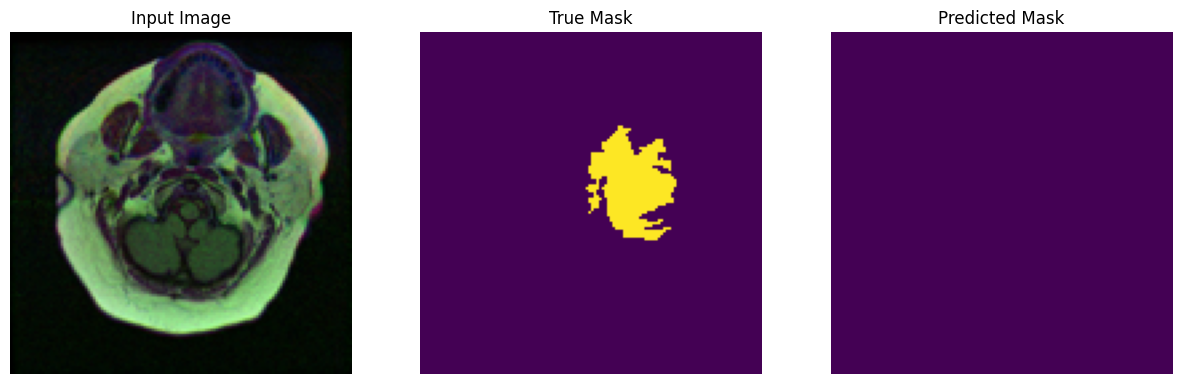

[display] rendered in 0.22s
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


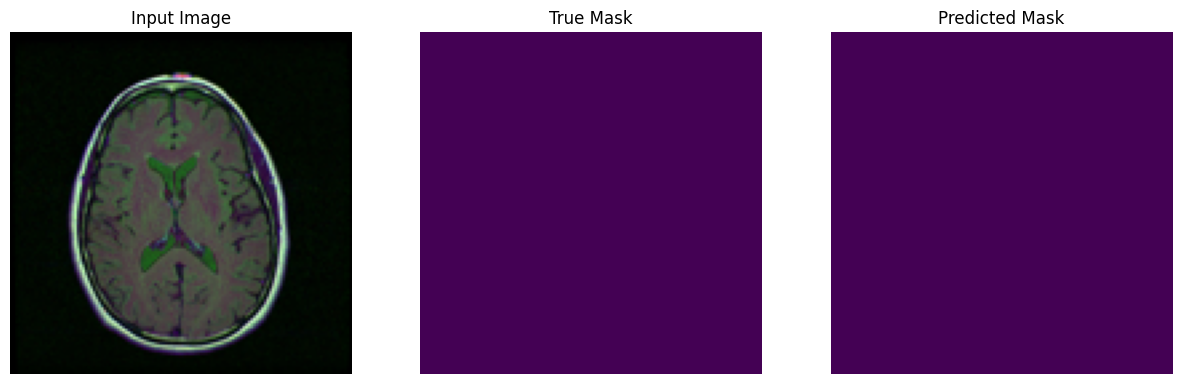

[display] rendered in 0.22s


In [14]:
loss     = model_history.history['loss']
val_loss = model_history.history['val_loss']
plt.figure()
plt.plot(model_history.epoch, loss,     'r',  label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss Value'); plt.ylim([0, 1]); plt.legend()
plt.savefig(DRIVE + '/results/segmentation_loss.png', dpi=120)
plt.show()

show_predictions(test_batches, 3)

## 8. Class weights (pixel imbalance)

In [15]:
def add_sample_weights(image, label):
  class_weights = tf.constant([1.0, 5.0])
  class_weights = class_weights / tf.reduce_sum(class_weights)
  sample_weights = tf.gather(class_weights, indices=tf.cast(label, tf.int32))
  return image, label, sample_weights

train_batches.map(add_sample_weights).element_spec

weighted_model = unet_model(OUTPUT_CLASSES)
weighted_model.compile(optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
weighted_model.fit(train_batches.map(add_sample_weights), epochs=1, steps_per_epoch=10)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.7889 - loss: 0.0829


## 9. Save model to Drive

In [16]:
model.save(DRIVE + '/models/brain_tumor_segmenter.h5')
print('Model saved to Drive ✓')

Model saved to Drive ✓


## 10. Discussion

**Dataset.** The same LGG Brain MRI dataset is used here for a different task: instead of classifying the whole slice, we predict a pixel-wise binary mask indicating which pixels belong to the tumor. This demonstrates that the same data can support both classification and segmentation — two fundamentally different problem formulations.

**Model.** This model implements the U-Net architechture. The pretrained MobileNetV2 encoder (frozen ImageNet weights) serves as the downsampling path, extracting features at progressively smaller spatial scales. The pix2pix decoder upsamples back to the original resolution using skip connections that preserve fine spatial detail from the encoder.

**Class imbalance.** This is more severe than any dataset in the course: tumor pixels can be less than 1% of all pixels in a slice. A naive model that predicts 'background' everywhere achieves 99%+ pixel accuracy but is clinically useless. This is addressed by multiplying the loss for tumor pixels by 5×, forcing the model to prioritise correctly detecting the small tumor region.